### Моделирование конечных автоматов

In [4]:
!pip -q install transitions

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.0/97.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 8.1 MB/s eta 0:00:00


In [5]:
import threading
from transitions import Machine
from transitions.core import MachineError

class VendingFSM:
    def __init__(self, select_timeout_s=10, dispense_timeout_s=8):
        self.outputs = {}
        self._timers = {}
        self.select_timeout_s = select_timeout_s
        self.dispense_timeout_s = dispense_timeout_s

    def set_outputs(self, **kwargs):
        self.outputs.update(kwargs)
        print(f"State = {self.state} | Output = {self.outputs}")

    def _start_timer(self, name: str, seconds: float, trigger_name: str):
        self._cancel_timer(name)

        def fire():
            fn = getattr(self, trigger_name, None)
            if fn is None:
                return
            try:
                print(f"Timer {name} fired -> {trigger_name}()")
                fn()
            except MachineError as e:
                print(f"Timer ignored (state changed): {e}")

        t = threading.Timer(seconds, fire)
        t.daemon = True
        self._timers[name] = t
        t.start()

    def _cancel_timer(self, name: str):
        t = self._timers.pop(name, None)
        if t is not None:
            t.cancel()

    def _cancel_all(self):
        for k in list(self._timers.keys()):
            self._cancel_timer(k)

    def on_enter_IDLE(self):
        self._cancel_all()
        self.set_outputs(display="Insert coin", coin_acceptor=True, motor=False, change=False, error=False)

    def on_enter_HAS_COIN(self):
        self.set_outputs(display="Select product", coin_acceptor=True, motor=False, change=False, error=False)

    def on_enter_SELECTING(self):
        self.set_outputs(
            display=f"Choosing... (timeout {self.select_timeout_s}s)",
            coin_acceptor=False, motor=False, change=False, error=False
        )
        self._start_timer("select", self.select_timeout_s, "select_timeout")

    def on_exit_SELECTING(self):
        self._cancel_timer("select")

    def on_enter_DISPENSING(self):
        self.set_outputs(
            display=f"Dispensing... (timeout {self.dispense_timeout_s}s)",
            coin_acceptor=False, motor=True, change=False, error=False
        )
        self._start_timer("dispense", self.dispense_timeout_s, "dispense_timeout")

    def on_exit_DISPENSING(self):
        self._cancel_timer("dispense")

    def on_enter_RETURN_CHANGE(self):
        self.set_outputs(display="Returning change", coin_acceptor=False, motor=False, change=True, error=False)

    def on_enter_OUT_OF_STOCK(self):
        self._cancel_all()
        self.set_outputs(display="Out of stock", coin_acceptor=False, motor=False, change=False, error=False)

    def on_enter_ERROR(self):
        self._cancel_all()
        self.set_outputs(display="ERROR: Jam detected", coin_acceptor=False, motor=False, change=False, error=True)

    def on_enter_SERVICE(self):
        self._cancel_all()
        self.set_outputs(display="Service mode", coin_acceptor=False, motor=False, change=False, error=False)


In [6]:
states = [
    "IDLE",
    "HAS_COIN",
    "SELECTING",
    "DISPENSING",
    "RETURN_CHANGE",
    "OUT_OF_STOCK",
    "ERROR",
    "SERVICE",
]

transitions_list = [
    {"trigger": "insert_coin",     "source": "IDLE",        "dest": "HAS_COIN"},
    {"trigger": "start_select",    "source": "HAS_COIN",    "dest": "SELECTING"},
    {"trigger": "confirm",         "source": "SELECTING",   "dest": "DISPENSING"},
    {"trigger": "product_dropped", "source": "DISPENSING",  "dest": "RETURN_CHANGE"},
    {"trigger": "change_returned", "source": "RETURN_CHANGE","dest":"IDLE"},
    {"trigger": "cancel",          "source": ["HAS_COIN", "SELECTING"], "dest": "RETURN_CHANGE"},
    {"trigger": "stock_empty",     "source": ["IDLE", "HAS_COIN", "SELECTING"], "dest": "OUT_OF_STOCK"},
    {"trigger": "restock",         "source": "OUT_OF_STOCK", "dest": "IDLE"},
    {"trigger": "select_timeout",   "source": "SELECTING",  "dest": "RETURN_CHANGE"},
    {"trigger": "dispense_timeout", "source": "DISPENSING", "dest": "ERROR"},
    {"trigger": "reset_error",      "source": "ERROR",      "dest": "IDLE"},
    {"trigger": "enter_service",    "source": "*",          "dest": "SERVICE"},
    {"trigger": "exit_service",     "source": "SERVICE",    "dest": "IDLE"},
]

In [7]:
fsm = VendingFSM(select_timeout_s=10, dispense_timeout_s=8)
machine = Machine(
    model=fsm,
    states=states,
    transitions=transitions_list,
    initial="IDLE",
    auto_transitions=False,
)

print("Initial state:", fsm.state)

Initial state: IDLE


**Тест 1: Успешная покупка**

In [8]:
import time

fsm.insert_coin()
fsm.start_select()
fsm.confirm()
threading.Timer(2, fsm.product_dropped).start()
threading.Timer(3, fsm.change_returned).start()
time.sleep(4)
print("Final state:", fsm.state)


State = HAS_COIN | Output = {'display': 'Select product', 'coin_acceptor': True, 'motor': False, 'change': False, 'error': False}
State = SELECTING | Output = {'display': 'Choosing... (timeout 10s)', 'coin_acceptor': False, 'motor': False, 'change': False, 'error': False}
State = DISPENSING | Output = {'display': 'Dispensing... (timeout 8s)', 'coin_acceptor': False, 'motor': True, 'change': False, 'error': False}
State = RETURN_CHANGE | Output = {'display': 'Returning change', 'coin_acceptor': False, 'motor': False, 'change': True, 'error': False}
State = IDLE | Output = {'display': 'Insert coin', 'coin_acceptor': True, 'motor': False, 'change': False, 'error': False}
Final state: IDLE


**Тест 2: Тайм-аут выбора**

In [9]:
import time

fsm.insert_coin()
fsm.start_select()

time.sleep(11)
print("State after timeout:", fsm.state)

fsm.change_returned()
print("Back to:", fsm.state)


State = HAS_COIN | Output = {'display': 'Select product', 'coin_acceptor': True, 'motor': False, 'change': False, 'error': False}
State = SELECTING | Output = {'display': 'Choosing... (timeout 10s)', 'coin_acceptor': False, 'motor': False, 'change': False, 'error': False}
Timer select fired -> select_timeout()
State = RETURN_CHANGE | Output = {'display': 'Returning change', 'coin_acceptor': False, 'motor': False, 'change': True, 'error': False}
State after timeout: RETURN_CHANGE
State = IDLE | Output = {'display': 'Insert coin', 'coin_acceptor': True, 'motor': False, 'change': False, 'error': False}
Back to: IDLE


**Тест 3: Заклинивание/ошибка выдачи**

In [10]:
import time

fsm.insert_coin()
fsm.start_select()
fsm.confirm()

time.sleep(9)
print("State after jam:", fsm.state)

fsm.reset_error()
print("After reset:", fsm.state)


State = HAS_COIN | Output = {'display': 'Select product', 'coin_acceptor': True, 'motor': False, 'change': False, 'error': False}
State = SELECTING | Output = {'display': 'Choosing... (timeout 10s)', 'coin_acceptor': False, 'motor': False, 'change': False, 'error': False}
State = DISPENSING | Output = {'display': 'Dispensing... (timeout 8s)', 'coin_acceptor': False, 'motor': True, 'change': False, 'error': False}
Timer dispense fired -> dispense_timeout()
State = ERROR | Output = {'display': 'ERROR: Jam detected', 'coin_acceptor': False, 'motor': False, 'change': False, 'error': True}
State after jam: ERROR
State = IDLE | Output = {'display': 'Insert coin', 'coin_acceptor': True, 'motor': False, 'change': False, 'error': False}
After reset: IDLE


In [11]:
!pip -q install graphviz

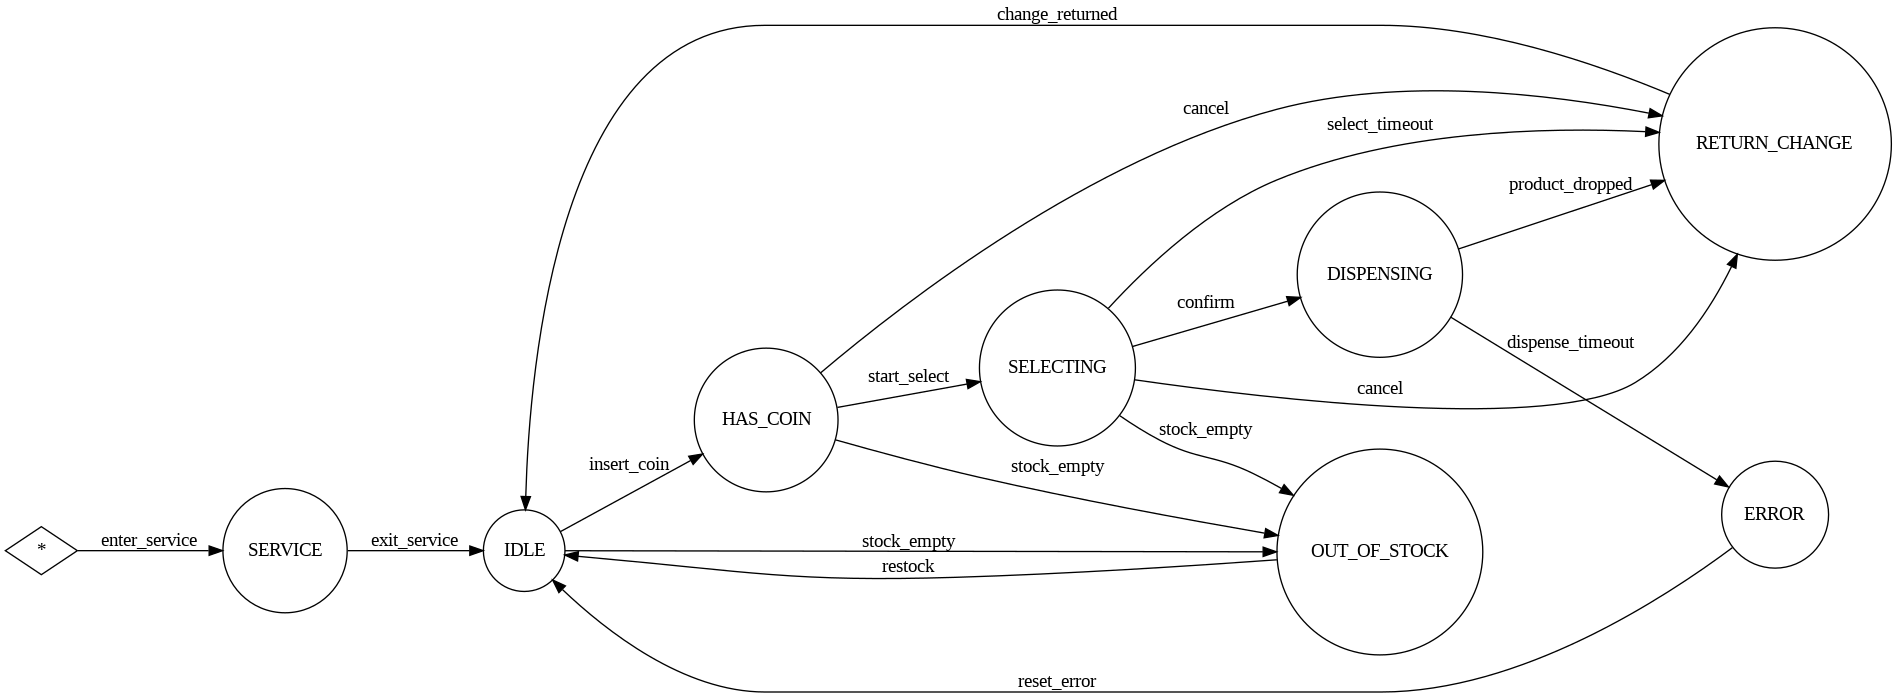

Saved: vending_fsm.png


In [12]:
from graphviz import Digraph
from IPython.display import Image, display

def build_fsm_graph(states, transitions_list, filename="vending_fsm", fmt="png"):
    dot = Digraph("FSM", format=fmt)
    dot.attr(rankdir="LR")
    dot.attr("node", shape="circle")

    dot.node("ANY", label="*", shape="diamond")

    for s in states:
        dot.node(s, label=s)

    for t in transitions_list:
        trig = t["trigger"]
        src = t["source"]
        dst = t["dest"]

        if src == "*":
            dot.edge("ANY", dst, label=trig)
        elif isinstance(src, list):
            for s in src:
                dot.edge(s, dst, label=trig)
        else:
            dot.edge(src, dst, label=trig)

    path = dot.render(filename, cleanup=True)
    return path

path = build_fsm_graph(states, transitions_list, filename="vending_fsm", fmt="png")
display(Image(path))
print("Saved:", path)
